# Automatic Nasion Detection

Fully autonomous nasion detection from 3D mesh geometry — no user click needed.

In [1]:
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt

import cedalion
import cedalion.io
import cedalion.plots
from cedalion import units
from cedalion.geometry.photogrammetry.anonymization import (
    detect_nasion_auto,
    detect_landmarks_from_nasion,
    anonymize_scan,
    AnonymizationConfig,
    AnonymizationMethod,
)

pv.set_jupyter_backend("server")

## 1. Load Scans

In [2]:
SCANS_FOLDER = "/home/ma7/BA/PG_Subjects11-15"
SUBJECT_NUMBERS = [11, 12, 13, 14, 15]

surfaces = {}
for subj in SUBJECT_NUMBERS:
    path = f"{SCANS_FOLDER}/Subject{subj}/Subject{subj}.obj"
    try:
        surfaces[subj] = cedalion.io.read_einstar_obj(path)
        print(f"Subject {subj}: {surfaces[subj].nvertices:,} vertices")
    except Exception as e:
        print(f"Subject {subj}: FAILED — {e}")

surface = surfaces[12]

Subject 11: 450,295 vertices
Subject 12: 624,121 vertices
Subject 13: 943,539 vertices
Subject 14: 725,532 vertices
Subject 15: 665,419 vertices


## 2. Auto-Detect Nasion

In [3]:
nasion, meta = detect_nasion_auto(surface)
nose_tip = meta["nose_tip"]

print(f"Nose tip: {nose_tip}")
print(f"Nasion:   {nasion}")
print(f"Confidence: {meta['confidence']:.2f}")

Nose tip: [ 72.030487 177.379486 433.952332]
Nasion:   [108.430481 148.957367 435.152344]
Confidence: 0.48


## 3. Visualize on Mesh

In [4]:
pvplt = pv.Plotter()
cedalion.plots.plot_surface(pvplt, surface, opacity=0.6)

pvplt.add_mesh(pv.Sphere(radius=4.0, center=nose_tip), color="green")
pvplt.add_point_labels([nose_tip + np.array([8, 0, 0])], ["Nose tip"],
                       font_size=14, text_color="green", bold=True, shape=None)

pvplt.add_mesh(pv.Sphere(radius=4.0, center=nasion), color="red")
pvplt.add_point_labels([nasion + np.array([8, 0, 0])], ["Nasion"],
                       font_size=14, text_color="red", bold=True, shape=None)

pvplt.add_mesh(pv.Line(nose_tip, nasion), color="yellow", line_width=3)
pvplt.add_text("Auto Nasion Detection", position="upper_left", font_size=14)
pvplt.show()

Widget(value='<iframe src="http://localhost:38775/index.html?ui=P_0x7fd7b17e65d0_0&reconnect=auto" class="pyvi…

## 4. Midsagittal Profile

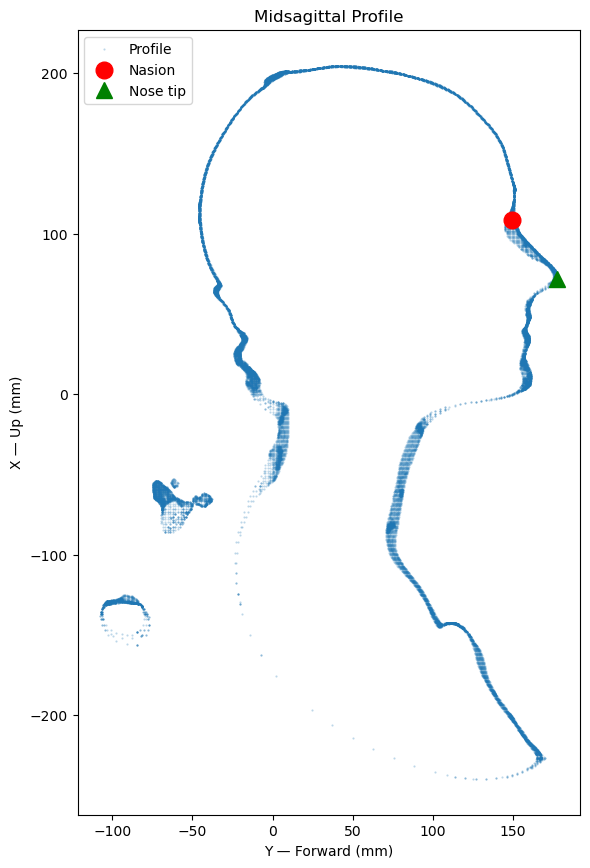

In [5]:
vertices = surface.mesh.vertices

# Midline vertices (within 5mm of nasion's Z)
mid_mask = np.abs(vertices[:, 2] - nasion[2]) < 5.0
mid_verts = vertices[mid_mask]

fig, ax = plt.subplots(figsize=(6, 10))
ax.plot(mid_verts[:, 1], mid_verts[:, 0], '.', markersize=1, alpha=0.3, label='Profile')
ax.plot(nasion[1], nasion[0], 'ro', markersize=12, label='Nasion')
ax.plot(nose_tip[1], nose_tip[0], 'g^', markersize=12, label='Nose tip')
ax.set_xlabel('Y — Forward (mm)')
ax.set_ylabel('X — Up (mm)')
ax.set_title('Midsagittal Profile')
ax.legend()
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

## 5. Test All Subjects

In [6]:
print(f"{'Subject':>8}  {'Nasion X':>10}  {'Nasion Y':>10}  {'Nasion Z':>10}  {'Conf':>6}")
print("-" * 52)

for subj, surf in surfaces.items():
    nz, m = detect_nasion_auto(surf)
    print(f"{subj:>8}  {nz[0]:>10.1f}  {nz[1]:>10.1f}  {nz[2]:>10.1f}  {m['confidence']:>6.2f}")

 Subject    Nasion X    Nasion Y    Nasion Z    Conf
----------------------------------------------------
      11       143.0       148.0       445.4    0.00
      12       108.4       149.0       435.2    0.48
      13       149.3       128.6       400.7    0.11
      14        59.3       187.7       394.7    0.44
      15       121.4       133.7       377.2    0.16


## 6. Full Pipeline — Auto Nasion to Anonymization

In [7]:
# Detect landmarks from auto nasion
landmarks = detect_landmarks_from_nasion(surface, nasion)
for label in landmarks.label.values:
    pos = landmarks.sel(label=label).pint.dequantify().values
    print(f"  {label}: [{pos[0]:.1f}, {pos[1]:.1f}, {pos[2]:.1f}]")

# Anonymize
result = anonymize_scan(
    surface=surface,
    anatomical_landmarks=landmarks,
    config=AnonymizationConfig(method=AnonymizationMethod.NOISE, noise_iterations=80),
    interactive=False,
    validate=True,
)

disp = result.vertex_displacements
print(f"\nFacial vertices: {result.facial_mask.sum():,}")
print(f"Max displacement: {disp.max():.2f} mm")
print(f"Mean face disp:  {disp[result.facial_mask].mean():.2f} mm")

  Nz: [108.4, 149.0, 435.2]
  Iz: [118.4, -46.2, 439.6]
  Cz: [204.9, 42.6, 437.6]
  LPA: [102.4, 47.4, 532.4]
  RPA: [80.0, 32.6, 350.6]

Facial vertices: 58,129
Max displacement: 8.27 mm
Mean face disp:  1.09 mm


In [8]:
pvplt = pv.Plotter(shape=(1, 2))

pvplt.subplot(0, 0)
cedalion.plots.plot_surface(pvplt, surface, opacity=1.0)
pvplt.add_mesh(pv.Sphere(radius=4.0, center=nasion), color="red")
pvplt.add_text("Original + Auto Nz", position="upper_left", font_size=14)

pvplt.subplot(0, 1)
cedalion.plots.plot_surface(pvplt, result.anonymized_surface, opacity=1.0)
pvplt.add_text("Anonymized", position="upper_left", font_size=14)

pvplt.link_views()
pvplt.show()

Widget(value='<iframe src="http://localhost:38775/index.html?ui=P_0x7fd7aeef29d0_1&reconnect=auto" class="pyvi…